# Notebook 1: Part 1 – Basic Analysis, Frequency Lists, Bigrams

**Setup and Basic Collection Statistics**

This cells installs required libraries, downloads stopwords, loads the documents.csv file,
and computes the basic collection statistics:
- Number of documents
- Total number of words
- Average document length
- Number of unique words (types)
- Average word length
- Average unique word length


In [12]:
# Install necessary packages (if not already installed)
!pip install pandas matplotlib scipy nltk tqdm

import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nltk
from collections import Counter
from tqdm import tqdm
import os
import requests

In [20]:
# Extract the zip file if not already extracted
zip_path = "wikIR1k.zip"
extract_dir = "wikIR1k"
if not os.path.exists(extract_dir):
    if os.path.exists(zip_path):
        print(f"Extracting {zip_path}...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(".")
        print("Extraction complete.")
    else:
        raise FileNotFoundError(f"{zip_path} not found. Please upload the dataset.")

# Path to the documents.csv file (now inside extracted folder)
csv_path = os.path.join(extract_dir, "documents.csv")

if not os.path.exists(csv_path):
    raise FileNotFoundError(f"{csv_path} not found. Please check the extracted contents.")

# Column name for the text (from the user's example)
text_col = "text_right"

# Download NLTK stopwords (fallback if the gist is unavailable)
nltk.download('stopwords')
from nltk.corpus import stopwords
stopwords_nltk = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [21]:
# Optionally download the custom stopword list from the gist (as per assignment)
stopword_url = "https://gist.githubusercontent.com/sebleier/554280/raw/7e0e4a1ce04c2bb7bd41089c9821dbcf6d0c786c/stopwords.txt"
try:
    response = requests.get(stopword_url)
    response.raise_for_status()
    custom_stopwords = set(response.text.splitlines())
    print(f"Loaded {len(custom_stopwords)} stopwords from gist.")
except:
    print("Could not fetch stopwords from gist, using NLTK stopwords instead.")
    custom_stopwords = stopwords_nltk

# Load the text column only, reading in chunks to avoid memory issues
print("Loading documents...")
doc_texts = []
chunk_size = 10000
with pd.read_csv(csv_path, usecols=[text_col], chunksize=chunk_size) as reader:
    for chunk in tqdm(reader, desc="Reading CSV"):
        doc_texts.extend(chunk[text_col].astype(str).tolist())

print(f"Loaded {len(doc_texts)} documents.")

Could not fetch stopwords from gist, using NLTK stopwords instead.
Loading documents...


Reading CSV: 37it [00:07,  4.75it/s]

Loaded 369721 documents.


In [22]:
# Tokenize each document (text is already tokenized, split on whitespace)
doc_tokens = [text.split() for text in doc_texts]

# Flatten all tokens
all_tokens = [token for tokens in doc_tokens for token in tokens]
total_words = len(all_tokens)

# Basic statistics
num_docs = len(doc_tokens)
avg_doc_len = total_words / num_docs
unique_words = set(all_tokens)
num_unique = len(unique_words)

total_chars = sum(len(token) for token in all_tokens)
avg_word_len = total_chars / total_words

total_chars_unique = sum(len(token) for token in unique_words)
avg_unique_word_len = total_chars_unique / num_unique

print("\n=== Basic Collection Statistics ===")
print(f"Number of documents: {num_docs}")
print(f"Total number of words: {total_words}")
print(f"Average document length (words): {avg_doc_len:.2f}")
print(f"Number of unique words (types): {num_unique}")
print(f"Average word length (overall): {avg_word_len:.2f}")
print(f"Average unique word length: {avg_unique_word_len:.2f}")


=== Basic Collection Statistics ===
Number of documents: 369721
Total number of words: 73093729
Average document length (words): 197.70
Number of unique words (types): 794568
Average word length (overall): 4.80
Average unique word length: 7.71


**Word Frequency List, Stopword Analysis, Zipf’s and Heaps’ Laws**

- Builds a sorted frequency list of all words.
- Counts stopword occurrences.
- Checks whether all top-30 words are in the stopword list.
- Recommends adding frequent non‑stopwords to the stopword list.
- Plots Zipf's law (rank vs. frequency on log‑log axes).
- Plots Heaps' law (vocabulary growth on log‑log axes).



=== Top 30 Most Frequent Words ===
the: 5311943
of: 2532382
in: 2355417
and: 2231007
a: 1557760
to: 1407261
was: 1078183
he: 685303
is: 676829
as: 661622
for: 616110
on: 610583
with: 535843
by: 526627
s: 497472
at: 482839
his: 440633
from: 432326
it: 398308
that: 306808
an: 279228
which: 221057
first: 217204
are: 206921
were: 205684
has: 195167
also: 186055
she: 184297
after: 166616
its: 161439

Total stopword occurrences: 29565380
Top‑30 words that are stopwords: ['the', 'of', 'in', 'and', 'a', 'to', 'was', 'he', 'is', 'as', 'for', 'on', 'with', 'by', 's', 'at', 'his', 'from', 'it', 'that', 'an', 'which', 'are', 'were', 'has', 'she', 'after', 'its']
Top‑30 words NOT in stopword list: {'first', 'also'}

Recommended candidates to add to stopword list (first 5):
  first: 217204
  also: 186055
  one: 157573
  new: 139850
  two: 136427


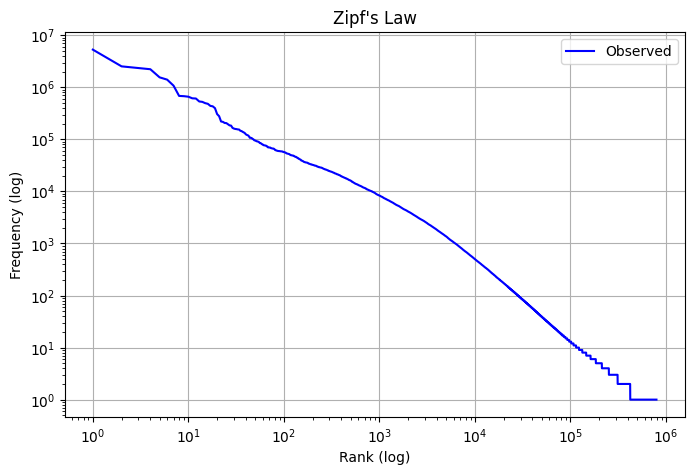

Computing vocabulary growth: 100%|██████████| 369721/369721 [00:07<00:00, 47374.51it/s]


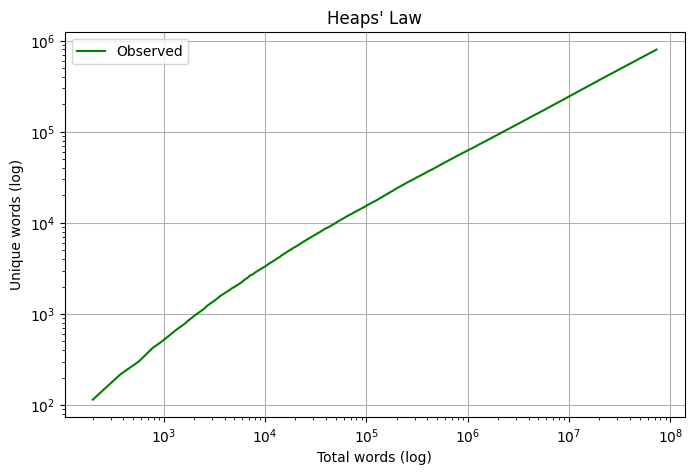

In [23]:
# Word frequency list
freq_counter = Counter(all_tokens)
freq_list = sorted(freq_counter.items(), key=lambda x: x[1], reverse=True)

print("\n=== Top 30 Most Frequent Words ===")
for word, count in freq_list[:30]:
    print(f"{word}: {count}")

# Stopword occurrences
stopword_occurrences = sum(count for word, count in freq_counter.items() if word in custom_stopwords)
print(f"\nTotal stopword occurrences: {stopword_occurrences}")

# Top‑30 words in stopword list
top30_words = [word for word, _ in freq_list[:30]]
top30_in_stopwords = [w for w in top30_words if w in custom_stopwords]
print(f"Top‑30 words that are stopwords: {top30_in_stopwords}")
print(f"Top‑30 words NOT in stopword list: {set(top30_words) - set(custom_stopwords)}")

# Recommend expanding stopwords
freq_non_stop = [(w, c) for w, c in freq_list if w not in custom_stopwords]
print("\nRecommended candidates to add to stopword list (first 5):")
for w, c in freq_non_stop[:5]:
    print(f"  {w}: {c}")

# Zipf's law: rank vs frequency
ranks = np.arange(1, len(freq_list)+1)
freqs = np.array([c for _, c in freq_list])
plt.figure(figsize=(8,5))
plt.loglog(ranks, freqs, 'b-', label='Observed')
plt.xlabel('Rank (log)')
plt.ylabel('Frequency (log)')
plt.title("Zipf's Law")
plt.legend()
plt.grid(True)
plt.show()

# Heaps' law: vocabulary growth as we read documents sequentially
cumulative_tokens = []
cumulative_unique = []
seen = set()
total_processed = 0
for tokens in tqdm(doc_tokens, desc="Computing vocabulary growth"):
    total_processed += len(tokens)
    seen.update(tokens)
    cumulative_tokens.append(total_processed)
    cumulative_unique.append(len(seen))

plt.figure(figsize=(8,5))
plt.loglog(cumulative_tokens, cumulative_unique, 'g-', label='Observed')
plt.xlabel('Total words (log)')
plt.ylabel('Unique words (log)')
plt.title("Heaps' Law")
plt.legend()
plt.grid(True)
plt.show()

**Bigram Frequency List and Analysis**
- Computes all unique word bigrams and their frequencies.
- Prints the top 20 bigrams.
- Proposes criteria for selecting bigrams as dictionary entries in an inverted index.

In [24]:
# Build bigram counter
bigram_counter = Counter()
for tokens in tqdm(doc_tokens, desc="Building bigrams"):
    for i in range(len(tokens)-1):
        bigram = (tokens[i], tokens[i+1])
        bigram_counter[bigram] += 1

print(f"\nNumber of unique bigrams: {len(bigram_counter)}")

# Top 20 bigrams
top_bigrams = bigram_counter.most_common(20)
print("\n=== Top 20 Bigrams ===")
for bigram, cnt in top_bigrams:
    print(f"{' '.join(bigram)}: {cnt}")

# Analyze top and propose criteria
print("\n=== Analysis and Criteria ===")
print("Proposed criteria for keeping a bigram as a dictionary entry in an inverted index:")
print("1. The bigram occurs frequently enough (e.g., frequency > 5).")
print("2. The bigram is not composed entirely of stopwords (to avoid noise).")
print("3. Optionally, the bigram should have a high mutual information score (not implemented here).")

candidates = [(b, c) for b, c in top_bigrams if c > 5]
def is_stopword_only(b):
    return all(w in custom_stopwords for w in b)

selected = [(b, c) for b, c in candidates if not is_stopword_only(b)]
print("\nSelected bigrams (frequency > 5 and not only stopwords):")
for bigram, cnt in selected[:15]:
    print(f"  {' '.join(bigram)}: {cnt}")

Building bigrams: 100%|██████████| 369721/369721 [02:33<00:00, 2413.67it/s]



Number of unique bigrams: 12993004

=== Top 20 Bigrams ===
of the: 768320
in the: 546863
to the: 256451
at the: 201351
and the: 170394
on the: 169708
he was: 163554
as a: 163073
for the: 159502
by the: 130810
with the: 120118
from the: 115219
the first: 104264
it was: 101387
as the: 96915
it is: 95880
is a: 82161
was a: 78342
in a: 76786
one of: 70278

=== Analysis and Criteria ===
Proposed criteria for keeping a bigram as a dictionary entry in an inverted index:
1. The bigram occurs frequently enough (e.g., frequency > 5).
2. The bigram is not composed entirely of stopwords (to avoid noise).
3. Optionally, the bigram should have a high mutual information score (not implemented here).

Selected bigrams (frequency > 5 and not only stopwords):
  the first: 104264
  one of: 70278


# Notebook 2: Part 2 – Morphological Processing



**Morphological Processing**

- Extracts the uploaded wikIR1k.zip file (if not already extracted).
- Loads documents.csv (columns: id_right, text_right).
- Applies Porter stemming (NLTK) to the entire collection.
- Applies spaCy lemmatization (requires downloading the small English model).
- Applies BERT tokenizer (HuggingFace).
- Computes and prints basic statistics for each version (total tokens, unique tokens, average token length).

In [1]:
# Install required libraries
!pip install nltk spacy transformers tqdm
!python -m spacy download en_core_web_sm

import zipfile
import nltk
import spacy
from transformers import BertTokenizer
from tqdm import tqdm
import pandas as pd
import os
from collections import Counter
from concurrent.futures import ProcessPoolExecutor, as_completed
import multiprocessing as mp

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 24.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
# Extract the zip file if not already extracted
zip_path = "wikIR1k.zip"
extract_dir = "wikIR1k"
if not os.path.exists(extract_dir):
    if os.path.exists(zip_path):
        print(f"Extracting {zip_path}...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(".")
        print("Extraction complete.")
    else:
        raise FileNotFoundError(f"{zip_path} not found. Please upload the dataset.")

# Path to the documents.csv file
csv_path = os.path.join(extract_dir, "documents.csv")
if not os.path.exists(csv_path):
    raise FileNotFoundError(f"{csv_path} not found. Please check the extracted contents.")

# Column name for the text
text_col = "text_right"

print("Loading documents...")
doc_texts = []
with pd.read_csv(csv_path, usecols=[text_col], chunksize=10000) as reader:
    for chunk in reader:
        doc_texts.extend(chunk[text_col].astype(str).tolist())
print(f"Loaded {len(doc_texts)} documents.")

# Tokenize original (already tokenized in the file)
original_tokens = [token for text in doc_texts for token in text.split()]

# ---------- Porter Stemmer (Parallel) ----------
def stem_text_chunk(chunk):
    porter = nltk.PorterStemmer()
    return [porter.stem(t) for text in chunk for t in text.split()]

print("\nApplying Porter stemmer (parallel)...")
# Split documents into chunks for parallel processing
num_cores = mp.cpu_count()
chunk_size = max(1, len(doc_texts) // (num_cores * 4))  # 4 chunks per core
chunks = [doc_texts[i:i+chunk_size] for i in range(0, len(doc_texts), chunk_size)]
stemmed_tokens = []
with ProcessPoolExecutor(max_workers=num_cores) as executor:
    futures = [executor.submit(stem_text_chunk, chunk) for chunk in chunks]
    for future in tqdm(as_completed(futures), total=len(futures), desc="Stemming"):
        stemmed_tokens.extend(future.result())

# ---------- spaCy Lemmatizer (Batch Processing) ----------
print("\nApplying spaCy lemmatizer (batch processing)...")
nlp = spacy.load("en_core_web_sm")
# Use nlp.pipe for efficient batched processing
lemmatized_tokens = []
# Process in batches of 1000 texts (adjust as needed)
batch_size = 1000
for i in tqdm(range(0, len(doc_texts), batch_size), desc="Lemmatizing"):
    batch = doc_texts[i:i+batch_size]
    docs = nlp.pipe(batch, batch_size=batch_size, n_process=2)  # use 2 processes
    for doc in docs:
        lemmatized_tokens.extend([token.lemma_ for token in doc])

# ---------- BERT Tokenizer ----------
print("\nApplying BERT tokenizer...")
bert_tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
bert_tokens = []
for text in tqdm(doc_texts, desc="BERT tokenization"):
    bert_tokens.extend(bert_tokenizer.tokenize(text))

# Helper to print stats
def print_stats(name, token_list):
    total = len(token_list)
    unique = len(set(token_list))
    avg_len = sum(len(t) for t in token_list) / total if total else 0
    print(f"{name:25} | Total tokens: {total:10} | Unique: {unique:10} | Avg length: {avg_len:.2f}")

print("\n=== Comparison of Versions ===")
print_stats("Original (tokenized)", original_tokens)
print_stats("Porter stemmer", stemmed_tokens)
print_stats("spaCy lemmatizer", lemmatized_tokens)
print_stats("BERT tokenizer", bert_tokens)

Extracting wikIR1k.zip...
Extraction complete.
Loading documents...
Loaded 369721 documents.

Applying Porter stemmer (parallel)...


Stemming: 100%|██████████| 9/9 [16:53<00:00, 112.57s/it]



Applying spaCy lemmatizer (batch processing)...


Lemmatizing:   0%|          | 0/370 [00:00<?, ?it/s]